# Interbank Contagion & Systemic Risk Analysis
This notebook builds a small synthetic banking system, models interbank lending, measures contagion with a simple DebtRank model, and compares failure scenarios using Monte Carlo simulation.

## Setup
Import the project functions and set the project paths.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

# The notebook is in notebooks/, so its parent is the project root.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from build_network import build_lending_network, save_edge_list
from create_plots import create_all_plots
from debtrank import calculate_debtrank, rank_banks_by_systemic_impact
from generate_bank_data import create_bank_data
from monte_carlo import run_monte_carlo, summarise_results

## Step 1: Synthetic bank data
We create five large core banks and fifteen smaller peripheral banks. Capital is each bank's initial loss-absorbing cushion.

In [2]:
banks = create_bank_data()
banks.to_csv(PROJECT_ROOT / 'data' / 'banks.csv', index=False)
banks

,bank_id,bank_type,total_assets,capital
0,Bank_01,Core,8624,862.4
1,Bank_02,Core,13418,1341.8
2,Bank_03,Core,12582,1258.2
3,Bank_04,Core,11072,1107.2
4,Bank_05,Core,11031,1103.1
5,Bank_06,Periphery,1788,178.8
6,Bank_07,Periphery,629,62.9
7,Bank_08,Periphery,1546,154.6
8,Bank_09,Periphery,802,80.2
9,Bank_10,Periphery,641,64.1


## Step 2: Lending network
An arrow from A to B means A lends to B. Core banks lend to one another, while peripheral banks borrow from one or two core banks.

In [3]:
network = build_lending_network(banks)
save_edge_list(network, PROJECT_ROOT / 'data' / 'lending_network.csv')
print(f'Banks: {network.number_of_nodes()}')
print(f'Lending relationships: {network.number_of_edges()}')

Banks: 20
Lending relationships: 43


## Step 3: DebtRank contagion
We default one bank. Its lenders lose the relevant exposure relative to their capital, which can cause further distress. The final score is the share of system assets affected by distress.

In [4]:
example_bank = 'Bank_01'
impact, distress = calculate_debtrank(network, example_bank)
print(f'Systemic impact of {example_bank}: {impact:.2%}')
pd.DataFrame({'bank_id': distress.keys(), 'distress': distress.values()}).sort_values('distress', ascending=False)

Systemic impact of Bank_01: 22.98%


,bank_id,distress
0,Bank_01,1.000000
1,Bank_02,0.187503
4,Bank_05,0.187496
2,Bank_03,0.187494
3,Bank_04,0.187493
5,Bank_06,0.000000
6,Bank_07,0.000000
7,Bank_08,0.000000
8,Bank_09,0.000000
9,Bank_10,0.000000


In [5]:
ranking = rank_banks_by_systemic_impact(network)
ranking.to_csv(PROJECT_ROOT / 'outputs' / 'systemic_importance_ranking.csv', index=False)
ranking.head(10)

,bank_id,systemic_impact
0,Bank_02,0.280497
1,Bank_03,0.271654
2,Bank_04,0.255676
3,Bank_05,0.255241
4,Bank_01,0.229771
5,Bank_12,0.049848
6,Bank_15,0.044795
7,Bank_14,0.044544
8,Bank_11,0.039980
9,Bank_17,0.037859


## Step 4: Monte Carlo simulation
We repeat the shock experiment 3,000 times. Random failure gives every bank the same chance of failure; size-weighted failure makes large banks more likely to fail.

In [6]:
results = run_monte_carlo(network, number_of_simulations=3000)
results.to_csv(PROJECT_ROOT / 'outputs' / 'monte_carlo_results.csv', index=False)
summary = summarise_results(results)
summary.to_csv(PROJECT_ROOT / 'outputs' / 'monte_carlo_summary.csv', index=False)
summary

,scenario,mean,median,percentile_95
0,Random failure,0.091384,0.037745,0.271654
1,Size-weighted failure,0.202162,0.255241,0.280497


## Step 5: Visualisations
The figures show the lending network, the two loss distributions, and the ten banks with the greatest systemic impact.

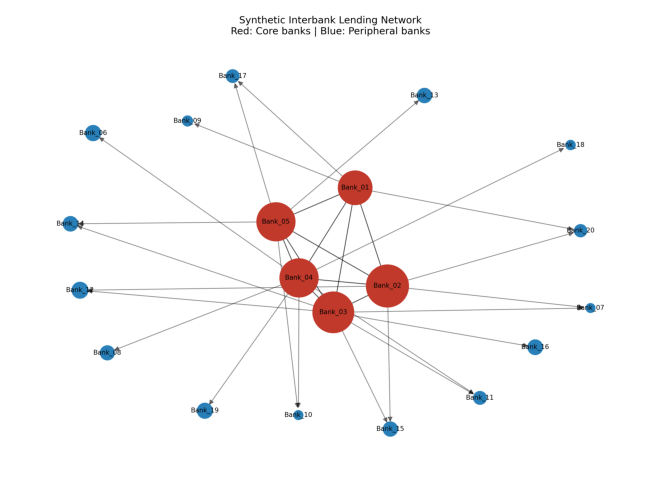

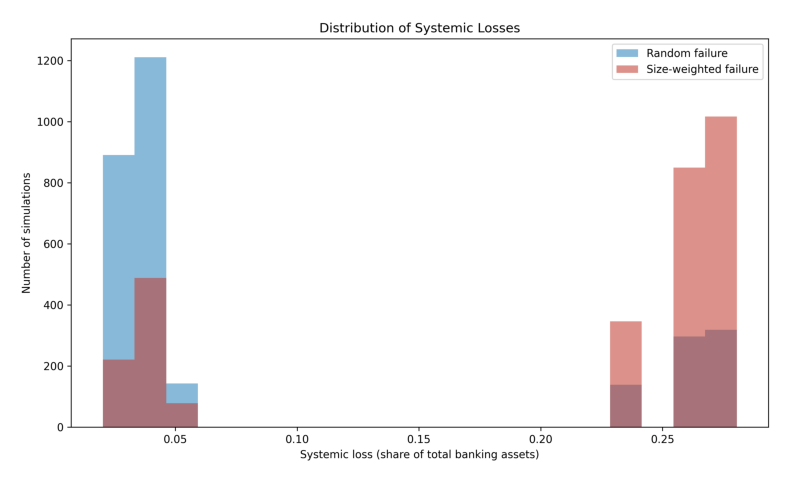

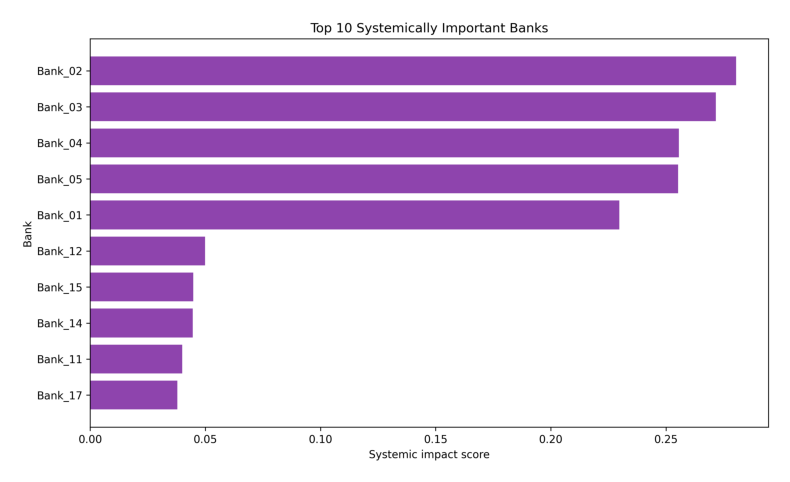

In [7]:
plot_paths = create_all_plots(network, results, ranking, PROJECT_ROOT / 'outputs')
for path in plot_paths.values():
    image = plt.imread(path)
    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

## Conclusion
Compare the random and size-weighted summary statistics above. In this synthetic system, failures that are more likely to involve large core banks should create larger systemic losses.